# Intraday Put-Call Parity Trades

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_FILE = Path("intraday_options_data_NFLX.xlsx")

info = pd.read_excel(DATA_FILE, sheet_name="Info")
prices = pd.read_excel(DATA_FILE, sheet_name="Prices", index_col=0, parse_dates=True)
prices.index.name = "timestamp"

info_map = info.set_index("Parameter")["Value"]
strike = float(str(info_map["Strike Price"]).replace("$", ""))
rate = float(str(info_map["Finance Rate"]).replace("%", "")) / 100
days_to_expiry = int(info_map["Days to Expiry"])

# ACT/360 with simple compounding
T = days_to_expiry / 360
pv_strike = strike / (1 + rate * T)

threshold = 0.30
quantity = 1_000
contract_size = 100


## 1.1

Mean absolute violation: $0.5573
Violations beyond ±$0.30: 8


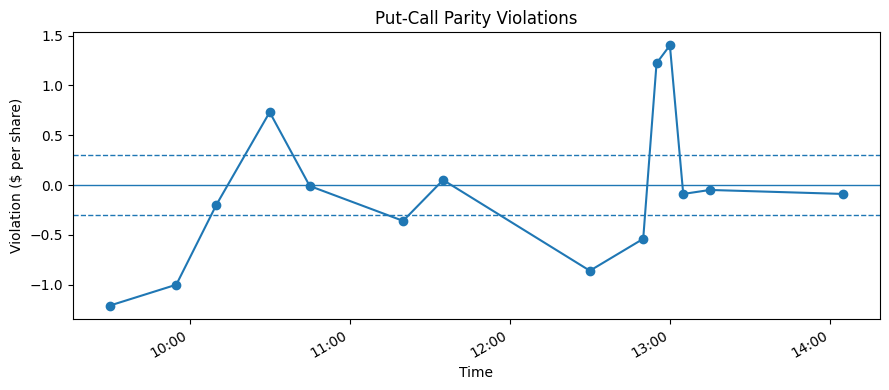

In [2]:
# Put-call parity: C + PV(K) = P + S
prices["violation"] = prices["call"] + pv_strike - prices["put"] - prices["underlying"]

mean_abs_violation = prices["violation"].abs().mean()
trade_mask = prices["violation"].abs() >= threshold
n_violations = int(trade_mask.sum())

print(f"Mean absolute violation: ${mean_abs_violation:.4f}")
print(f"Violations beyond ±${threshold:.2f}: {n_violations}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(prices.index, prices["violation"], marker="o")
ax.axhline(threshold, linestyle="--", linewidth=1)
ax.axhline(-threshold, linestyle="--", linewidth=1)
ax.axhline(0, linewidth=1)
ax.set_title("Put-Call Parity Violations")
ax.set_xlabel("Time")
ax.set_ylabel("Violation ($ per share)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 1.2

Total PnL for the day: $731,737.06


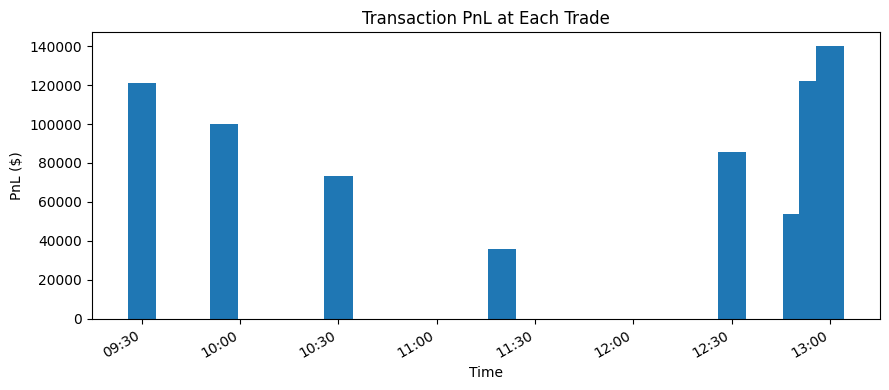

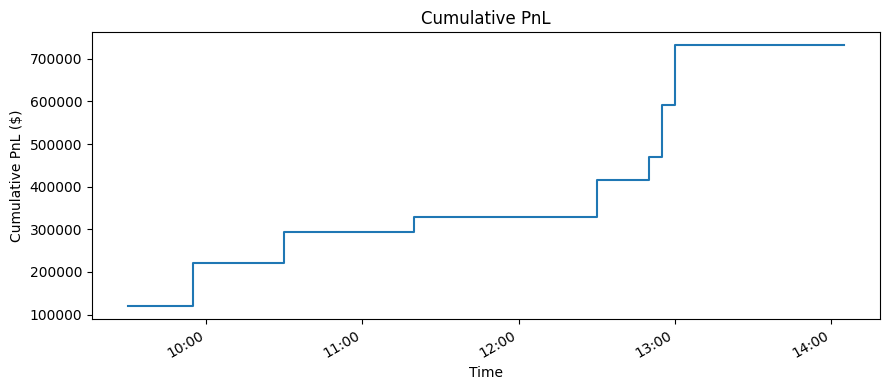

In [3]:
notional_scale = quantity * contract_size
prices["transaction_pnl"] = np.where(
    trade_mask,
    prices["violation"].abs() * notional_scale,
    0.0,
)
prices["cumulative_pnl"] = prices["transaction_pnl"].cumsum()

trades = prices.loc[trade_mask].copy()
total_pnl = prices["transaction_pnl"].sum()

print(f"Total PnL for the day: ${total_pnl:,.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(trades.index, trades["transaction_pnl"], width=0.006)
ax.set_title("Transaction PnL at Each Trade")
ax.set_xlabel("Time")
ax.set_ylabel("PnL ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.step(prices.index, prices["cumulative_pnl"], where="post")
ax.set_title("Cumulative PnL")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 1.3

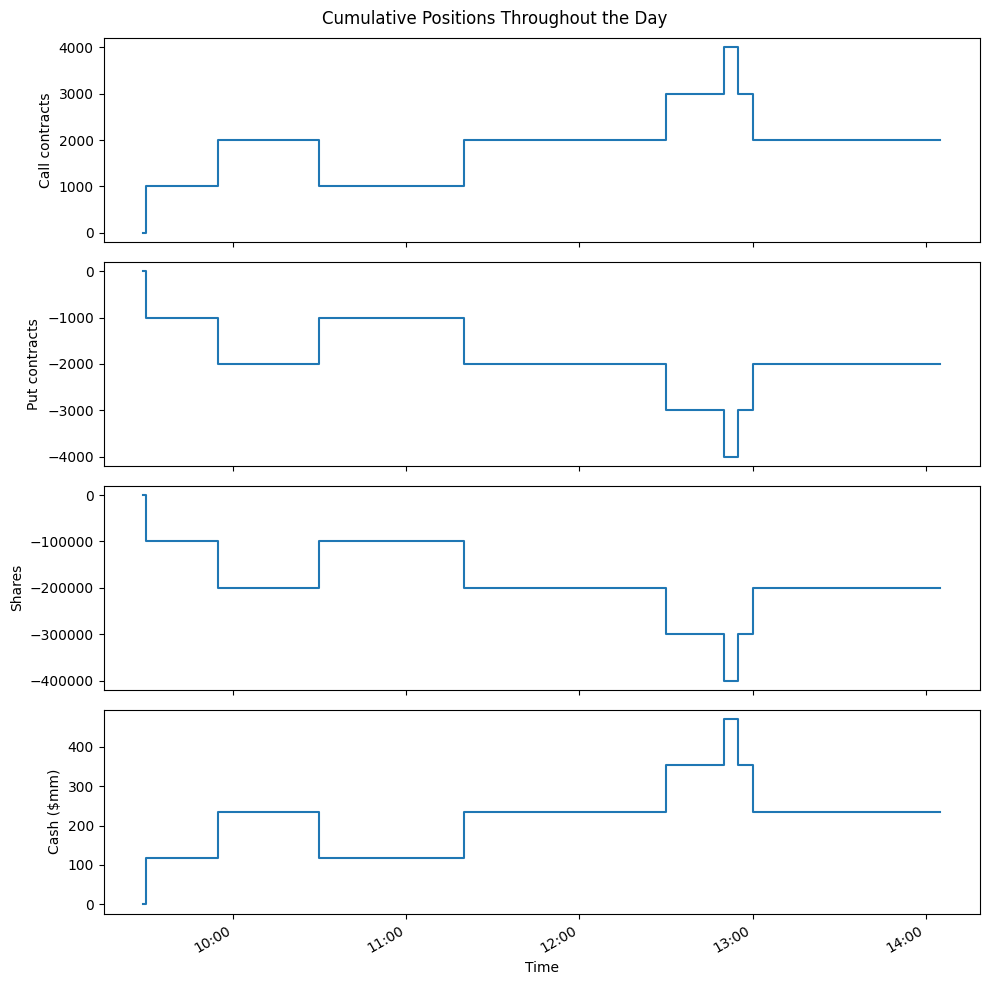

,Min,Max
shares,-400000,0
call contracts,0,4000
put contracts,-4000,0


In [4]:
# sign = +1 when C + PV(K) is expensive, -1 when it is cheap
trade_sign = np.where(trade_mask, np.sign(prices["violation"]), 0)

positions = pd.DataFrame(index=prices.index)
positions["call contracts"] = np.cumsum(-trade_sign * quantity)
positions["put contracts"] = np.cumsum(trade_sign * quantity)
positions["shares"] = np.cumsum(trade_sign * quantity * contract_size)
positions["cash"] = np.cumsum(-trade_sign * pv_strike * quantity * contract_size)

# Include the zero position before the first trade.
start_time = positions.index[0] - pd.Timedelta(minutes=1)
position_path = pd.concat([
    pd.DataFrame(
        {"call contracts": [0.0], "put contracts": [0.0], "shares": [0.0], "cash": [0.0]},
        index=[start_time],
    ),
    positions,
])

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].step(position_path.index, position_path["call contracts"], where="post")
axes[0].set_ylabel("Call contracts")

axes[1].step(position_path.index, position_path["put contracts"], where="post")
axes[1].set_ylabel("Put contracts")

axes[2].step(position_path.index, position_path["shares"], where="post")
axes[2].set_ylabel("Shares")

axes[3].step(position_path.index, position_path["cash"] / 1_000_000, where="post")
axes[3].set_ylabel("Cash ($mm)")
axes[3].set_xlabel("Time")
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.suptitle("Cumulative Positions Throughout the Day")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

position_summary = pd.DataFrame({
    "Min": [
        position_path["shares"].min(),
        position_path["call contracts"].min(),
        position_path["put contracts"].min(),
    ],
    "Max": [
        position_path["shares"].max(),
        position_path["call contracts"].max(),
        position_path["put contracts"].max(),
    ],
}, index=["shares", "call contracts", "put contracts"]).astype(int)

position_summary


## 1.4

The calculation assumes the observed prices are executable with no transaction costs. In practice, bid-ask spreads and fees across the stock, call, and put legs would reduce the apparent arbitrage PnL.